In [1]:
import pandas as pd
from itertools import combinations
import numpy as np

In [2]:
#Loading in the roads data file
df1 = pd.read_csv('./data/_roads3.csv')

#Filtering on the N1 and N2 roads
roads = ['N1', 'N2'] + [f'N{i}' for i in range(100, 300)]
dfN = df1[df1['road'].isin(roads)]


In [3]:
#Creating the source and sink for the new data frame, based on the minimal and maximal chainage
source_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmin()]
sink_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmax()]

df_proc = (
    pd.concat([source_rows, sink_rows])
    .drop_duplicates(subset=['road', 'chainage', 'lrp'])
    .sort_values(['road', 'chainage'])
    .reset_index(drop=True)
)
df_proc


,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit..."
2,N101,0.000,LRPS,23.454139,91.212861,NaN,Others,Start of Road from N120 at Balutopa
3,N101,6.021,LRPE,23.459306,91.253389,NaN,Others,End of road Bibir bazar Bridge
4,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati
5,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail
6,N103,0.000,LRPS,23.957028,91.115528,NaN,Others,Road start from N102 at Kuatali.
7,N103,4.779,LRPE,23.996889,91.109278,NaN,Others,Intersection with N102 at Ghaturia.
8,N104,0.000,LRPS,23.009667,91.399416,NaN,Others,Intersection with Z1031
9,N104,49.630,LRPE,22.825749,91.101444,NaN,Others,Meet with Z1441& Z1405 at Sonapur.


In [4]:
#Calculate the total lenght of a road based on it's chainage
df_proc['total_length'] = df_proc.groupby('road')['chainage'].transform('max')
#Filter out roads that have a length smaller then 25 km
df_filtered = (df_proc[df_proc['total_length'] > 25]).copy()

In [5]:
#Adjust dataframe for the resulting dataset
df_filtered['model_type'] = 'sourcesink'
df_filtered['length'] = 0
df_filtered['condition'] = None

df_filtered = df_filtered[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage']]
df_filtered.rename(columns={'lrp': 'id'}, inplace=True)

df_filtered

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254
4,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
5,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,None,0.000
9,N104,LRPE,sourcesink,Meet with Z1441& Z1405 at Sonapur.,22.825749,91.101444,0,None,49.630
10,N105,LRPS,sourcesink,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,0,None,0.000
11,N105,LRP048,sourcesink,"B.Bridge 83 km,Tangail 60 km / End of Road In...",23.989527,90.358222,0,None,48.870
12,N106,LRPS,sourcesink,Start of Road from Oxygen More,22.393555,91.821583,0,None,0.000
13,N106,LRPE,sourcesink,The road ends Infront of DC Bunglow,22.648527,92.201833,0,None,66.850


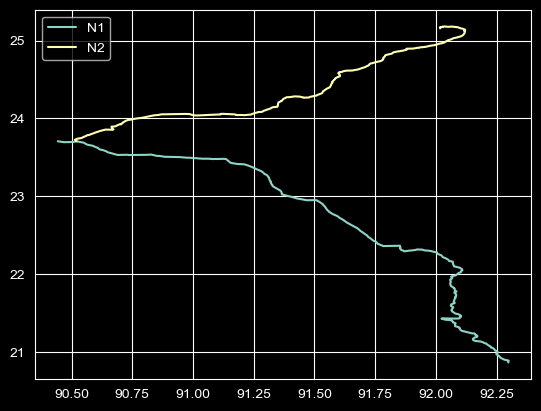

In [6]:
# Visual inspection of N1 and N2
import matplotlib.pyplot as plt

df_plot = dfN[dfN['road'].isin(['N1', 'N2'])]

for road, data in df_plot.groupby('road'):
    plt.plot(data['lon'], data['lat'], label=road)

plt.legend()
plt.show()

In [7]:
#Function to calculate distances between locations on longitude and latitude, based on Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

In [8]:
df_n1 = dfN[dfN['road'] == 'N1'].copy()
df_n2 = dfN[dfN['road'] == 'N2'].copy()
#Make dataframe with every possible combination of points on N1 and N2
df_cross = df_n1.merge(df_n2, how='cross', suffixes=('_n1', '_n2'))

#Calculate the distances between every point between N1 and N2
df_cross['distance'] = haversine(
    df_cross['lat_n1'],
    df_cross['lon_n1'],
    df_cross['lat_n2'],
    df_cross['lon_n2']
)
#Find intersections by setting a threshold distance of 0.05 km
intersections = df_cross[df_cross['distance'] < 0.05]

#Dataframe showing the intersections of N1 and N2 based on the threshold distance of 0.05 km
intersections[['road_n1','chainage_n1','lrp_n1',
               'road_n2','chainage_n2','lrp_n2',
               'distance']]



,road_n1,chainage_n1,lrp_n1,road_n2,chainage_n2,lrp_n2,distance
15062,N1,8.763,LRP009a,N2,0.0,LRPS,0.020374


In [9]:
#Find all possible combinations of roads
roads = df_filtered['road'].unique()
road_pairs = list(combinations(roads, 2))


In [10]:
#Find all intersections by checking the distances of every point between two roads, and calculate if this
#distance is smaller then the threshold of 0.05 km
all_intersections = []

for r1, r2 in road_pairs:

    df_r1 = dfN[dfN['road'] == r1]
    df_r2 = dfN[dfN['road'] == r2]

    df_cross = df_r1.merge(df_r2, how='cross', suffixes=('_1', '_2'))

    df_cross['distance'] = haversine(
        df_cross['lat_1'],
        df_cross['lon_1'],
        df_cross['lat_2'],
        df_cross['lon_2']
    )

    inter = df_cross[df_cross['distance'] < 0.05]

    all_intersections.append(inter)

intersections = pd.concat(all_intersections, ignore_index=True)
intersections[['road_1','chainage_1','lrp_1',
               'road_2','chainage_2','lrp_2',
               'distance']]



,road_1,chainage_1,lrp_1,road_2,chainage_2,lrp_2,distance
0,N1,81.801,LRP083a,N102,0.000,LRPS,0.048258
1,N1,81.829,LRP084,N102,0.000,LRPS,0.019837
2,N1,81.846,LRP084a,N102,0.000,LRPS,0.002835
3,N1,145.409,LRP148a,N104,1.878,LRP001a,0.009078
4,N1,11.936,LRP012c,N105,0.000,LRPS,0.002831
5,N1,8.763,LRP009a,N2,0.000,LRPS,0.020374
6,N102,82.682,LRPE,N2,85.823,LRP086a,0.033466
7,N105,12.803,LRP012a,N2,11.464,LRP012a,0.029759
8,N105,12.803,LRP012a,N2,11.476,LRP012b,0.023229
9,N105,12.803,LRP012a,N2,11.517,LRP012c,0.037868


In [11]:
#Group points that are based on the same intersection
intersection_groups = {}
group_id = 0

for _, row in intersections.iterrows():

    a = (row['road_1'], row['lrp_1'])
    b = (row['road_2'], row['lrp_2'])

    if a in intersection_groups:
        intersection_groups[b] = intersection_groups[a]

    elif b in intersection_groups:
        intersection_groups[a] = intersection_groups[b]

    else:
        intersection_groups[a] = group_id
        intersection_groups[b] = group_id
        group_id += 1

In [12]:
#Extract the intersection point from side 1 of each road pair and of side 2
df_i1 = intersections[['road_1','lrp_1','chainage_1']].rename(columns={
    'road_1':'road',
    'lrp_1':'lrp',
    'chainage_1':'chainage'
})
df_i2 = intersections[['road_2','lrp_2','chainage_2']].rename(columns={
    'road_2':'road',
    'lrp_2':'lrp',
    'chainage_2':'chainage'
})
#Combine both sides into one intersection-node table
df_intersections = pd.concat([df_i1, df_i2])

#Merge with the original road dataset
df_intersections = df_intersections.merge(
    dfN,
    on=['road','lrp','chainage'],
    how='left'
)

#Adjust dataframe for the resulting dataset
df_intersections['model_type'] = 'intersection'
df_intersections['length'] = 0
df_intersections['condition'] = None

#Map each node to its intersection group
df_intersections['intersection_group'] = df_intersections.apply(
    lambda r: intersection_groups.get((r['road'], r['lrp']), None),
    axis=1
)
#Finalise the dataframe
df_intersections = df_intersections[['road','lrp','model_type','name','lat','lon','length','condition','chainage', 'intersection_group']]
df_intersections = df_intersections.rename(columns={'lrp':'id'})





In [13]:
# Group nearby points within each road and assign them a shared ID
def sync_geographical_ids(df, threshold=0.05):
    final_groups = []

    #Group dataframe per road
    for road, group in df.groupby('road'):
        #Reset reference locations for the current road
        master_locations = []
        synced_ids = []

        #Work on a copy to avoid modifying the grouped slice directly
        group = group.copy()

        for index, row in group.iterrows():
            current_lat = row['lat']
            current_lon = row['lon']
            current_id = row['id']

            match_found = False
            #Compare current point to previously stored reference locations
            for master_lat, master_lon, master_id in master_locations:
                distance = haversine(current_lat, current_lon, master_lat, master_lon)

                if distance <= threshold:
                    #Reuse the existing ID if the point matches a known location
                    synced_ids.append(master_id)
                    match_found = True
                    break

            if not match_found:
                #No match, new unique location for this road
                master_locations.append((current_lat, current_lon, current_id))
                synced_ids.append(current_id)

        #Replace original IDs with synchronized IDs
        group['id'] = synced_ids

        #Remove duplicates
        group = group.drop_duplicates('id')

        final_groups.append(group)

    #Combine all processed roads into one dataframe
    return pd.concat(final_groups).reset_index(drop=True)



In [14]:
#Use the sync_geographical_ids on the dataframe
df_unique = sync_geographical_ids(df_intersections)

In [15]:
#Combine the filtered road points and the unique nodes into one dataframe and sort by road and chainage
df_final = pd.concat([df_filtered, df_unique], ignore_index=True)
df_final = df_final.sort_values(['road', 'chainage']).reset_index(drop=True)

In [16]:
def remove_overlapping_sourcesinks(df, threshold=0.05):
    indices_to_drop = []

    for road, group in df.groupby('road'):
        # Reset index binnen de groep voor makkelijk itereren
        group = group.sort_values('chainage')
        indices = group.index.tolist()

        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                idx_a = indices[i]
                idx_b = indices[j]

                dist = haversine(
                    df.at[idx_a, 'lat'], df.at[idx_a, 'lon'],
                    df.at[idx_b, 'lat'], df.at[idx_b, 'lon']
                )

                if dist <= threshold:
                    type_a = df.at[idx_a, 'model_type']
                    type_b = df.at[idx_b, 'model_type']

                    # Verwijder de sourcesink als de andere een ander type is
                    if type_a == 'sourcesink' and type_b != 'sourcesink':
                        indices_to_drop.append(idx_a)
                    elif type_b == 'sourcesink' and type_a != 'sourcesink':
                        indices_to_drop.append(idx_b)
                    # Als beide sourcesink zijn (dubbeling op start/eind), verwijder de tweede
                    elif type_a == 'sourcesink' and type_b == 'sourcesink':
                        indices_to_drop.append(idx_b)

    # Verwijder duplicaten uit de drop-lijst en gooi ze uit de dataframe
    df_cleaned = df.drop(index=list(set(indices_to_drop))).reset_index(drop=True)
    print(f"Systeem: {len(set(indices_to_drop))} overtollige sourcesinks verwijderd.")
    return df_cleaned

# Direct toepassen op je huidige dataframe
df_final = remove_overlapping_sourcesinks(df_final)

Systeem: 10 overtollige sourcesinks verwijderd.


In [17]:
df_final

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000,NaN
1,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763,3.0
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936,2.0
3,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801,0.0
4,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409,1.0
5,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254,NaN
6,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000,0.0
7,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,4.0
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,None,0.000,NaN
9,N104,LRP001a,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,0,None,1.878,1.0


In [18]:
#Loading in the Bridges data
df_BMMS = pd.read_excel('./data/BMMS_overview.xlsx')

#Selecting the columns that we need
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()

roads = df_filtered['road'].unique()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'].isin(roads)]

bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()

display(bridges_BMMS.head(20))


,road,name,LRPName,length,chainage,lat,lon,condition,name_clean
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A,.
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A,.
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A,KANCHPURBRIDGE.
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A,NOYAPARACULVERT
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A,ADUPURCULVERT
5,N1,NAYABARI KASPUR BOX CULVERT,LRP011a,8.30,11.296,23.692360,90.540918,A,NAYABARIKASPURBOXCULVERT
6,N1,KHAS PARA BOX CULVERT,LRP012a,9.30,12.239,23.688412,90.548559,A,KHASPARABOXCULVERT
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.10,12.253,23.688320,90.548650,A,DAWANBAGBOXCULVERT
8,N1,Madanpur Bridge.(L),LRP013a,27.50,12.660,23.685583,90.551208,A,MADANPURBRIDGE.(L)
9,N1,MADAN PUR (R),LRP013a,26.30,12.660,23.685583,90.551208,A,MADANPUR(R)


In [19]:
#Dropping duplicates
df_unique = bridges_BMMS.drop_duplicates(
    subset=['chainage','lat','lon'],
    keep='first'
).reset_index(drop=True)

#Filtering on bridges only
df_unique['model_type'] = 'bridge'

df_bridges = df_unique[['road','LRPName','model_type','name','lat','lon','length','condition','chainage']]

df_bridges = df_bridges.rename(columns={'LRPName':'id'})

df_final = pd.concat([df_final, df_bridges], ignore_index=True)

df_final = df_final.sort_values(['road','chainage']).reset_index(drop=True)

df_final = (
    df_final
    .assign(
        prefix=(
            df_final["name"]
            .str.replace('.', '')
            .str.lower()
            .str.strip()
            .str.extract(r"^([^(]+)", expand=False)
        )
    )
    .drop_duplicates(subset=['road','prefix'], keep='first')
    .drop(columns="prefix")
)

df_final.head(20)


,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.000,NaN
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800,NaN
3,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.763,3.0
4,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976,NaN
5,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.543,NaN
6,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A,10.880,NaN
7,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A,10.897,NaN
8,N1,LRP011a,bridge,NAYABARI KASPUR BOX CULVERT,23.692360,90.540918,8.30,A,11.296,NaN
9,N1,LRP011c,bridge,NAYABARI BOX CULVERT,23.690912,90.545462,10.60,B,11.808,NaN
10,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0.00,None,11.936,2.0


In [20]:
final_df_with_links = []

for road, road_df in df_final.groupby('road'):

    road_df = road_df.sort_values('chainage').reset_index(drop=True)

    for j in range(len(road_df)):
        row = road_df.iloc[j]

        # eerste node (source)
        if j == 0:
            final_df_with_links.append(row)
            continue

        prev = road_df.iloc[j-1]

        # link locatie (midden van de twee nodes)
        lat_link = (row['lat'] + prev['lat']) / 2
        lon_link = (row['lon'] + prev['lon']) / 2

        # length of the road
        link_length = (row['chainage'] - prev['chainage']) * 1000

        link = {
            'road': road,
            'id': None,
            'model_type': 'link',
            'name': 'Link',
            'lat': lat_link,
            'lon': lon_link,
            'length': link_length,
            'condition': None,
            'chainage': (row['chainage'] + prev['chainage']) / 2
        }

        final_df_with_links.append(pd.Series(link))
        final_df_with_links.append(row)

final_df_with_links = pd.DataFrame(final_df_with_links).reset_index(drop=True)

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.0000,NaN
1,N1,None,link,Link,23.702383,90.451097,1800.00,None,0.9000,NaN
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.8000,NaN
3,N1,None,link,Link,23.702411,90.490194,6963.00,None,5.2815,NaN
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.7630,3.0
5,N1,None,link,Link,23.705572,90.522371,213.00,None,8.8695,NaN
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.9760,NaN
7,N1,None,link,Link,23.700730,90.529157,1567.00,None,9.7595,NaN
8,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.5430,NaN
9,N1,None,link,Link,23.695395,90.536337,337.00,None,10.7115,NaN


In [21]:
intersection_length = 20  # meters

final_df_with_links.loc[
    final_df_with_links['model_type'] == 'intersection',
    'length'
] = intersection_length

In [22]:
for i in range(1, len(final_df_with_links)-1):

    if final_df_with_links.loc[i, 'model_type'] == 'link':

        prev_len = final_df_with_links.loc[i-1, 'length']
        next_len = final_df_with_links.loc[i+1, 'length']

        final_df_with_links.loc[i, 'length'] = (
            final_df_with_links.loc[i, 'length']
            - prev_len/2
            - next_len/2
        )

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.000,None,0.0000,NaN
1,N1,None,link,Link,23.702383,90.451097,1794.350,None,0.9000,NaN
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.300,A,1.8000,NaN
3,N1,None,link,Link,23.702411,90.490194,6947.350,None,5.2815,NaN
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.7630,3.0
5,N1,None,link,Link,23.705572,90.522371,5.885,None,8.8695,NaN
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.230,A,8.9760,NaN
7,N1,None,link,Link,23.700730,90.529157,1365.885,None,9.7595,NaN
8,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.000,B,10.5430,NaN
9,N1,None,link,Link,23.695395,90.536337,329.850,None,10.7115,NaN


In [23]:
final_df_with_links['id'] = 100000 + (final_df_with_links.index + 1)

mask = final_df_with_links['model_type'] == 'intersection'

final_df_with_links.loc[mask, 'id'] = (
    final_df_with_links[mask]
    .groupby('intersection_group')['id']
    .transform('first')
)

In [24]:
final_df_with_links.drop('intersection_group', axis=1, inplace=True)


In [25]:
display(final_df_with_links.head(20))


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,100001,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.000,None,0.0000
1,N1,100002,link,Link,23.702383,90.451097,1794.350,None,0.9000
2,N1,100003,bridge,.,23.698739,90.458861,11.300,A,1.8000
3,N1,100004,link,Link,23.702411,90.490194,6947.350,None,5.2815
4,N1,100005,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.7630
5,N1,100006,link,Link,23.705572,90.522371,5.885,None,8.8695
6,N1,100007,bridge,Kanch pur Bridge.,23.705060,90.523214,394.230,A,8.9760
7,N1,100008,link,Link,23.700730,90.529157,1365.885,None,9.7595
8,N1,100009,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.000,B,10.5430
9,N1,100010,link,Link,23.695395,90.536337,329.850,None,10.7115


In [26]:
#check if everything is connected:

import networkx as nx

G = nx.Graph()

for road, group in final_df_with_links.groupby('road'):
    nodes = group['id'].tolist()
    for i in range(len(nodes) - 1):
        G.add_edge(nodes[i], nodes[i+1])

num_components = nx.number_connected_components(G)
print(f"seperate island-networks: {num_components}")

seperate island-networks: 2


In [27]:
#check how big the islands are
components = list(nx.connected_components(G))
for i, c in enumerate(components):
    print(f"Island {i+1} has {len(c)} components.")

#which roads are at which islands?
for i, c in enumerate(components):
    roads_in_component = final_df_with_links[final_df_with_links['id'].isin(c)]['road'].unique()
    print(f"Island {i+1} has roads: {roads_in_component}")

Island 1 has 2709 components.
Island 2 has 203 components.
Island 1 has roads: ['N1' 'N102' 'N104' 'N105' 'N2' 'N204' 'N207' 'N208']
Island 2 has roads: ['N106']


In [28]:
def get_nearest(point, search_df):
    dists = haversine(point['lat'], point['lon'], search_df['lat'], search_df['lon'])
    idx = dists.idxmin()
    return dists[idx], search_df.loc[idx]

n106 = final_df_with_links[final_df_with_links.road == 'N106'].sort_values('chainage')

n1_n2 = final_df_with_links[final_df_with_links.road.isin(['N1', 'N2'])]

d_start, r_start = get_nearest(n106.iloc[0], n1_n2)
d_end, r_end = get_nearest(n106.iloc[-1], n1_n2)

print(f"Start N106: {d_start:.3f} km from {r_start['road']} (Ch {r_start['chainage']})")
print(f"End N106: {d_end:.3f} km from {r_end['road']} (Ch {r_end['chainage']})")

Start N106: 3.315 km from N1 (Ch 236.99099999999999)
End N106: 45.638 km from N1 (Ch 263.2425)


In [29]:
#create intersection between N106 and N1
target_n1_chainage = 236.991
n106_start_chainage = 0.0

#find the row in N1
n1_mask = (final_df_with_links['road'] == 'N1') & (final_df_with_links['chainage'].between(target_n1_chainage - 0.01, target_n1_chainage + 0.01))

if n1_mask.any():
    #get ID from N1
    n1_id = final_df_with_links.loc[n1_mask, 'id'].values[0]

   #put model type to intersection
    final_df_with_links.loc[n1_mask, 'model_type'] = 'intersection'

    #find starting point from N106
    n106_mask = (final_df_with_links['road'] == 'N106') & (final_df_with_links['chainage'] == n106_start_chainage)

    if n106_mask.any():
        #make it the same ID
        final_df_with_links.loc[n106_mask, 'id'] = n1_id

        #also make intersection
        final_df_with_links.loc[n106_mask, 'model_type'] = 'intersection'

#create overview
id_counts = final_df_with_links['id'].value_counts()
shared_ids = id_counts[id_counts > 1].index

intersection_overzicht = final_df_with_links[(final_df_with_links['id'].isin(shared_ids)) & (final_df_with_links['model_type'] == 'intersection')]

#group
overzicht_tabel = intersection_overzicht.groupby('id').agg({
    'road': lambda x: ' & '.join(sorted(x.unique())),
    'model_type': 'first',
    'name': 'first',
    'chainage': 'first'
}).reset_index()

display(overzicht_tabel[overzicht_tabel['road'].str.contains('N106')])

,id,road,model_type,name,chainage
4,100418,N1 & N106,intersection,Link,236.991


In [30]:
# make sure that per road we only have one intersection ID
# sort on chainage to keep the most logical point (the first one encountered)
final_df_clean = final_df_with_links.sort_values(['road', 'chainage']).drop_duplicates(subset=['road', 'id'], keep='first')

# update your original dataframe variable
final_df_with_links = final_df_clean.reset_index(drop=True)

In [31]:
display(final_df_with_links.head(10))

display(final_df_with_links[final_df_with_links['model_type'] == 'intersection'])


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,100001,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.000,None,0.0000
1,N1,100002,link,Link,23.702383,90.451097,1794.350,None,0.9000
2,N1,100003,bridge,.,23.698739,90.458861,11.300,A,1.8000
3,N1,100004,link,Link,23.702411,90.490194,6947.350,None,5.2815
4,N1,100005,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.7630
5,N1,100006,link,Link,23.705572,90.522371,5.885,None,8.8695
6,N1,100007,bridge,Kanch pur Bridge.,23.705060,90.523214,394.230,A,8.9760
7,N1,100008,link,Link,23.700730,90.529157,1365.885,None,9.7595
8,N1,100009,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.000,B,10.5430
9,N1,100010,link,Link,23.695395,90.536337,329.850,None,10.7115


,road,id,model_type,name,lat,lon,length,condition,chainage
4,N1,100005,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.763
18,N1,100019,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,20.000,None,11.936
126,N1,100127,intersection,Box culvert,23.478944,91.117722,20.000,None,81.801
236,N1,100237,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,20.000,None,145.409
417,N1,100418,intersection,Link,22.364795,91.813098,10046.175,None,236.991
1177,N102,100127,intersection,Start of road from N1 Mainamati,23.478972,91.118194,20.000,None,0.000
1357,N102,101358,intersection,Meet with N 2 at Sanail,24.050611,91.114667,20.000,None,82.682
1364,N104,100237,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,20.000,None,1.878
1443,N105,100019,intersection,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,20.000,None,0.000
1457,N105,101458,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,20.000,None,12.803


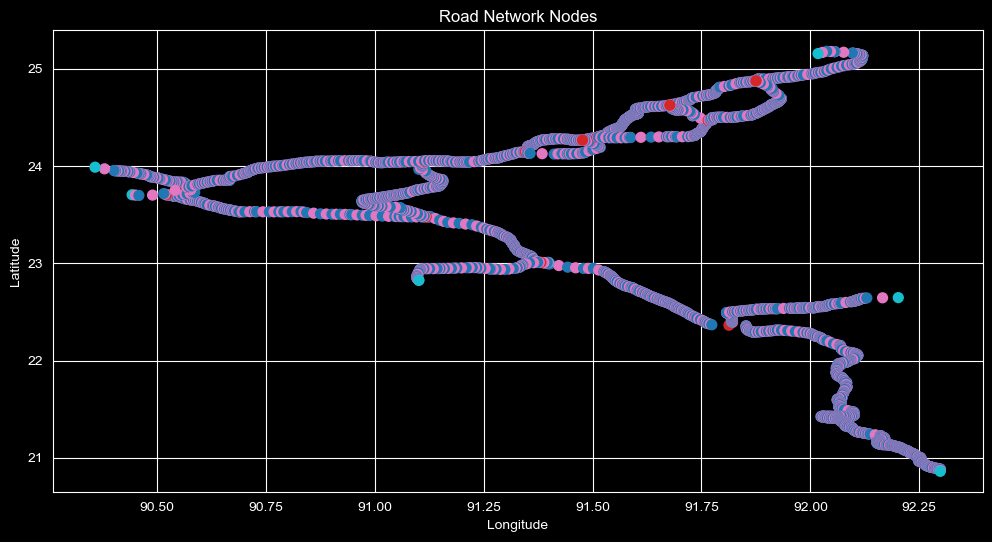

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# kleur automatisch per model_type
colors = final_df_with_links['model_type'].astype('category').cat.codes

plt.scatter(
    final_df_with_links['lon'],
    final_df_with_links['lat'],
    c=colors,
    cmap='tab10',   # mooie colormap
    s=50
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Road Network Nodes')

plt.show()

In [33]:
final_df_with_links.to_csv('data/data_intersectionsN1N2.csv', na_rep="None")